# Word-Level Seq2Seq with Attention — English-Russian Translator

Train a GRU encoder-decoder with Bahdanau-style additive attention
(`nn.GRU` + `Attention`) to translate English sentences into Russian, on the
[opus-100](https://huggingface.co/datasets/Helsinki-NLP/opus-100) en-ru corpus.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
from collections.abc import Callable
from pathlib import Path

import pandas as pd
import sentencepiece as spm
import torch
import torch.nn.functional as F
from colorama import Fore, Style
from datasets import load_dataset
from dotenv import load_dotenv
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset

from dl_roadmap.engine import Trainer, TrainerConfig
from dl_roadmap.utils import (
    LoggerConfig,
    load_model,
    notify_model_trained,
    save_model,
    seed_everything,
    setup_logger,
)
from dl_roadmap.visualization import plot_attention_matrix, plot_training_history

In [3]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

load_dotenv()
seed_everything()
setup_logger(LoggerConfig(log_level="WARNING"))

In [4]:
DATA_DIR = Path("../data/processed/09_translator")
MODEL_DIR = Path("../models/09_translator")

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

## Dataset

In [5]:
dataset = load_dataset("Helsinki-NLP/opus-100", "en-ru")

train_df = pd.DataFrame(
    dataset["train"].shuffle(seed=42).select(range(250_000))["translation"]
)
val_df = pd.DataFrame(dataset["test"]["translation"])

### Overview

In [6]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   en      250000 non-null  str  
 1   ru      250000 non-null  str  
dtypes: str(2)
memory usage: 48.3 MB

====== val ======
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   en      2000 non-null   str  
 1   ru      2000 non-null   str  
dtypes: str(2)
memory usage: 495.2 KB


In [7]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                  en                                                 ru
0  Please highlight those laws which were recomme...  Просьба сообщить, в какие именно законы было р...
1                       I want you to see something.                      Я хочу показать тебе кое-что.
2                               We have a good case.                                У нас хорошее дело.
3  But in the meantime, we need to find a way to ...        Но сейчас нам надо как-то двигаться дальше.
4  We also commend the Secretary-General and his ...  Мы также воздаем должное Генеральному секретар...

====== val ======
                                                  en                                                 ru
0                            If you only stay there.                             Только бы не вылететь.
1  I don't know how you do it, Pop, carrying thes...  И как ты только справляешься, папа, таская эти...

In [8]:
print(f"{Fore.RED}Missing Values in Each Column:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
    print(missing_df)

Missing Values in Each Column:

====== train ======
    Missing Count  Missing %
en              0        0.0
ru              0        0.0

====== val ======
    Missing Count  Missing %
en              0        0.0
ru              0        0.0


### Preprocessing

In [9]:
def prepare(df: pd.DataFrame) -> pd.DataFrame:
    """Filters noisy opus-100 pairs by length, script, and alignment heuristics.

    Args:
        df: DataFrame with raw ``en`` and ``ru`` text columns.

    Returns:
        The filtered DataFrame with stripped text, index reset.
    """
    en, ru = df["en"].str.strip(), df["ru"].str.strip()
    en_words, ru_words = en.str.split().str.len(), ru.str.split().str.len()
    length_ratio = en.str.len() / ru.str.len().clip(lower=1)

    mask = (
        en_words.between(3, 25)
        & ru_words.between(3, 25)
        & length_ratio.between(0.4, 2.5)
        & en.str.contains(r"[a-z]", case=False, regex=True)
        & ru.str.contains(r"[а-яё]", case=False, regex=True)
        & (en.str.count(r"[A-Za-z]") / en.str.len().clip(lower=1) > 0.5)  # noqa: PLR2004
        & (ru.str.count(r"[а-яА-ЯёЁ]") / ru.str.len().clip(lower=1) > 0.5)  # noqa: PLR2004
        & (en.str.lower() != ru.str.lower())
        & ~en.str.contains(r"https?://|www\.", regex=True)
    )

    clean = df.assign(en=en, ru=ru)[mask]
    clean = clean.drop_duplicates(subset="en").drop_duplicates(subset="ru")
    return clean.reset_index(drop=True)


train_df = prepare(train_df)
val_df = prepare(val_df)

### SentencePiece

In [10]:
for lang in ("en", "ru"):
    (DATA_DIR / f"{lang}.txt").write_text("\n".join(train_df[lang]), encoding="utf-8")

In [11]:
for lang in ("en", "ru"):
    spm.SentencePieceTrainer.train(
        input=str(DATA_DIR / f"{lang}.txt"),
        model_prefix=str(MODEL_DIR / lang),
        vocab_size=8000,
        model_type="unigram",
        pad_id=3,
        unk_id=2,
        bos_id=0,
        eos_id=1,
        pad_piece="<PAD>",
        unk_piece="<UNK>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
    )

I0000 00:00:1784040375.086297  962741 sentencepiece_trainer.cc:105] Starts training with : 
trainer_spec {
  input: ../data/processed/09_translator/en.txt
  input_format: 
  model_prefix: ../models/09_translator/en
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 2
  bos_id: 0
  eos_id: 1
  pad_id: 3
  unk_piece: <UNK>
  bos_piece: <BOS>
  eos_piece: <EOS>
  p

In [12]:
sp_en = spm.SentencePieceProcessor(model_file=str(MODEL_DIR / "en.model"))
sp_ru = spm.SentencePieceProcessor(model_file=str(MODEL_DIR / "ru.model"))

### PyTorch Dataset

In [13]:
class EnRuDataset(Dataset):
    """Sentence-pair dataset for English-Russian translation."""

    MAX_SEQ_LEN = 60

    def __init__(
        self,
        df: pd.DataFrame,
        sp_en: spm.SentencePieceProcessor,
        sp_ru: spm.SentencePieceProcessor,
    ) -> None:
        """Initializes the dataset.

        Args:
            df: DataFrame with raw ``en`` and ``ru`` text columns.
            sp_en: SentencePiece model used to encode the ``en`` column.
            sp_ru: SentencePiece model used to encode the ``ru`` column.
        """
        super().__init__()

        self.df = df.copy()
        self.sp_en = sp_en
        self.sp_ru = sp_ru

        self._prepare()

    def _prepare(self) -> None:
        """Encodes both columns to token ids and drops overlong pairs."""
        self.df["en_ids"] = self.df["en"].apply(lambda s: self._encode(self.sp_en, s))
        self.df["ru_ids"] = self.df["ru"].apply(
            lambda s: self._encode(self.sp_ru, s, add_bos=False)
        )

        mask = (self.df["en_ids"].str.len() <= self.MAX_SEQ_LEN) & (
            self.df["ru_ids"].str.len() <= self.MAX_SEQ_LEN
        )

        self.df = self.df[mask].reset_index(drop=True)

    def _encode(
        self,
        sp: spm.SentencePieceProcessor,
        sentence: str,
        add_bos: bool = True,
    ) -> list[int]:
        """Encodes a raw sentence into EOS-terminated subword token ids.

        Args:
            sp: SentencePiece model used to encode ``sentence``.
            sentence: The raw sentence to encode.
            add_bos: Whether to prepend ``<BOS>``.

        Returns:
            The subword token ids.
        """
        ids = sp.encode(sentence, out_type=int)
        if add_bos:
            return [sp.bos_id(), *ids, sp.eos_id()]
        return [*ids, sp.eos_id()]

    def __len__(self) -> int:
        """Returns the number of sentence pairs in the dataset."""
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Returns the input/target token id sequences for a sentence pair.

        Args:
            idx: Index of the sentence pair in the dataset.

        Returns:
            A tuple of the source (``en``) and target (``ru``) token id
            sequences, both as long tensors.
        """
        row = self.df.iloc[idx]
        input_data, output_data = row["en_ids"], row["ru_ids"]

        x = torch.tensor(input_data, dtype=torch.long)
        y = torch.tensor(output_data, dtype=torch.long)

        return x, y

### Collation

In [14]:
pad_id = sp_en.pad_id()


def collate_fn(
    batch: list[tuple[torch.Tensor, torch.Tensor]],
) -> tuple[torch.Tensor, torch.Tensor]:
    """Pads a batch of source/target token id sequences to the same length.

    Args:
        batch: A list of (source, target) token id sequence pairs of
            variable length.

    Returns:
        A tuple of the padded source and target token id tensors, both
        padded with ``pad_id`` and shaped ``batch_size x max_seq_len``.
    """
    xs, ys = zip(*batch)

    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = pad_sequence(ys, batch_first=True, padding_value=pad_id)

    return xs, ys

In [15]:
train_dataset = EnRuDataset(train_df, sp_en, sp_ru)
val_dataset = EnRuDataset(val_df, sp_en, sp_ru)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=collate_fn,
)

## Model

In [16]:
class EncoderRNN(nn.Module):
    """GRU-based sequence encoder."""

    def __init__(
        self,
        input_size: int,
        embedding_dim: int = 256,
        hidden_size: int = 512,
        num_layers: int = 2,
        dropout: float = 0.2,
        pad_id: int = 0,
    ) -> None:
        """Initializes the model.

        Args:
            input_size: Number of distinct tokens in the input vocabulary.
            embedding_dim: Size of the token embedding vectors.
            hidden_size: Size of the RNN hidden state.
            num_layers: Number of stacked RNN layers.
            dropout: Dropout probability applied to the embedded input.
            pad_id: Token id used for padding, ignored by the embedding.
        """
        super().__init__()

        self.pad_id = pad_id

        self.embedding = nn.Embedding(
            num_embeddings=input_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id,
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encodes a batch of input sequences.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.

        Returns:
            A tuple of the per-step hidden states and the final hidden state.
        """
        lengths = (x != self.pad_id).sum(dim=1).cpu()

        embedding = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(
            embedding,
            lengths,
            batch_first=True,
            enforce_sorted=False,
        )

        output, hidden = self.gru(packed)
        output, _ = pad_packed_sequence(
            output, batch_first=True, total_length=x.size(1)
        )
        return output, hidden

In [17]:
class Attention(nn.Module):
    """Bahdanau-style additive attention."""

    def __init__(self, hidden_size: int) -> None:
        """Initializes the attention layers.

        Args:
            hidden_size: Size of the query and key vectors.
        """
        super().__init__()

        self.w_1 = nn.Linear(hidden_size, hidden_size)
        self.w_2 = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1)

    def forward(
        self,
        query: torch.Tensor,
        keys: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Computes a context vector for the current decoder step.

        Args:
            query: Current decoder hidden state, shaped
                ``batch_size x 1 x hidden_size``.
            keys: Encoder per-step hidden states, shaped
                ``batch_size x seq_len x hidden_size``.
            mask: True at padded source positions, excluded from attention.

        Returns:
            A tuple of the context vector and the attention weights.
        """
        scores = self.v(torch.tanh(self.w_1(query) + self.w_2(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1), float("-inf"))

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

In [18]:
class DecoderRNN(nn.Module):
    """GRU-based autoregressive decoder with attention and weight tying."""

    MAX_LENGTH = 64

    def __init__(
        self,
        output_size: int,
        hidden_size: int = 1024,
        num_layers: int = 1,
        dropout: float = 0.2,
        bos_id: int = 1,
    ) -> None:
        """Initializes the model.

        Args:
            output_size: Number of distinct tokens in the vocabulary.
            hidden_size: Size of the RNN hidden state.
            num_layers: Number of stacked RNN layers.
            dropout: Dropout probability applied to the embedded input.
            bos_id: Token id used to seed the first decoding step.
        """
        super().__init__()

        self.bos_id = bos_id

        self.dropout = nn.Dropout(dropout)
        self.embedding = nn.Embedding(output_size, hidden_size)
        nn.init.normal_(self.embedding.weight, mean=0.0, std=hidden_size**-0.5)
        self.attention = Attention(hidden_size)

        self.gru = nn.GRU(
            input_size=hidden_size * 2,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, output_size)

        # Weight tying
        self.fc.weight = self.embedding.weight

    def forward(
        self,
        encoder_outputs: torch.Tensor,
        encoder_hidden: torch.Tensor,
        target: torch.Tensor | None = None,
        teacher_forcing_ratio: float = 1.0,
        src_mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Decodes an output sequence from the encoder state.

        Args:
            encoder_outputs: Encoder per-step hidden states, shaped
                ``batch_size x src_len x hidden_size``.
            encoder_hidden: Encoder final hidden state, initializes the
                decoder's hidden state.
            target: Ground-truth token ids for teacher forcing; if None,
                decoding is free-running for ``MAX_LENGTH`` steps.
            teacher_forcing_ratio: Probability of feeding the ground-truth
                token instead of the model's own prediction.
            src_mask: True at padded source positions, excluded from
                attention.

        Returns:
            A tuple of the per-step logits, the final hidden state, and
            the per-step attention weights.
        """
        device = encoder_outputs.device
        target_length = target.size(1) if target is not None else 0
        steps = target_length if target is not None else self.MAX_LENGTH

        batch_size = encoder_outputs.size(0)
        decoder_input = torch.full(
            (batch_size, 1),
            self.bos_id,
            dtype=torch.long,
            device=device,
        )
        hidden = encoder_hidden
        outputs = []
        attentions = []

        for index in range(steps):
            output, hidden, attn_weights = self.forward_step(
                dec_input=decoder_input,
                hidden=hidden,
                enc_outputs=encoder_outputs,
                src_mask=src_mask,
            )
            outputs.append(output)
            attentions.append(attn_weights)

            if index < target_length:
                # Teacher forcing: feed the ground-truth token.
                use_tf = torch.rand(batch_size, device=device) < teacher_forcing_ratio
                _, topi = output.topk(1)
                greedy_input = topi.squeeze(-1).detach()
                decoder_input = torch.where(
                    use_tf.unsqueeze(1), target[:, index].unsqueeze(1), greedy_input
                )
            else:
                # Greedy decoding: feed the most likely token back in.
                _, topi = output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        outputs = torch.cat(outputs, dim=1)
        attentions = torch.cat(attentions, dim=1)

        return outputs, hidden, attentions

    def forward_step(
        self,
        dec_input: torch.Tensor,
        hidden: torch.Tensor,
        enc_outputs: torch.Tensor,
        src_mask: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Runs a single decoding step.

        Args:
            dec_input: Token ids for the current step, shaped
                ``batch_size x 1``.
            hidden: Decoder hidden state from the previous step.
            enc_outputs: Encoder per-step hidden states, shaped
                ``batch_size x src_len x hidden_size``.
            src_mask: True at padded source positions, excluded from
                attention.

        Returns:
            A tuple of the step logits, the updated hidden state, and the
            attention weights.
        """
        embedding = self.dropout(self.embedding(dec_input))

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, enc_outputs, mask=src_mask)
        dec_input = torch.cat((embedding, context), dim=2)

        output, hidden = self.gru(dec_input, hidden)
        output = self.fc(self.dropout(output))

        return output, hidden, attn_weights

In [19]:
class Translator(nn.Module):
    """Attention-based encoder-decoder model for English-Russian translation."""

    def __init__(
        self,
        sp_en: spm.SentencePieceProcessor,
        sp_ru: spm.SentencePieceProcessor,
    ) -> None:
        """Initializes the encoder and decoder.

        Args:
            sp_en: Source-language (``en``) SentencePiece model.
            sp_ru: Target-language (``ru``) SentencePiece model.
        """
        super().__init__()

        self.enc_pad_id = sp_en.pad_id()

        self.teacher_forcing_ratio = 1.0

        self.encoder = EncoderRNN(sp_en.get_piece_size(), pad_id=self.enc_pad_id)
        self.decoder = DecoderRNN(sp_ru.get_piece_size(), bos_id=sp_ru.bos_id())

    def _bridge_hidden(self, encoder_hidden: torch.Tensor) -> torch.Tensor:
        """Adapts the encoder's final hidden state to seed the decoder.

        Args:
            encoder_hidden: Encoder final hidden state, shaped
                ``(num_layers * 2) x batch_size x encoder_hidden_size``.

        Returns:
            The decoder's initial hidden state, shaped
            ``1 x batch_size x decoder_hidden_size``.
        """
        return torch.cat((encoder_hidden[-2], encoder_hidden[-1]), dim=-1).unsqueeze(0)

    def forward(self, x: torch.Tensor, y: torch.Tensor | None = None) -> torch.Tensor:
        """Encodes ``x`` and decodes its translation.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.
            y: Target token ids for teacher forcing; if None, decoding is
                free-running.

        Returns:
            Logits over the vocabulary for each decoded step.
        """
        enc_output, enc_hidden = self.encoder.forward(x)
        dec_output, _, _ = self.decoder.forward(
            encoder_outputs=enc_output,
            encoder_hidden=self._bridge_hidden(enc_hidden),
            target=y,
            teacher_forcing_ratio=self.teacher_forcing_ratio,
            src_mask=(x == self.enc_pad_id),
        )

        return dec_output

    def forward_with_attention(
        self, x: torch.Tensor, y: torch.Tensor | None = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Encodes ``x`` and decodes its translation with attention weights.

        Args:
            x: Input token ids of shape ``batch_size x seq_len``.
            y: Target token ids for teacher forcing; if None, decoding is
                free-running.

        Returns:
            A tuple of the per-step logits and the attention weights.
        """
        enc_output, enc_hidden = self.encoder.forward(x)
        dec_output, _, dec_attention = self.decoder.forward(
            encoder_outputs=enc_output,
            encoder_hidden=self._bridge_hidden(enc_hidden),
            target=y,
            teacher_forcing_ratio=self.teacher_forcing_ratio,
            src_mask=(x == self.enc_pad_id),
        )

        return dec_output, dec_attention

## Training

In [ ]:
def teacher_forcing_callback(
    model: Translator,
    k: float = 20.0,
    min_ratio: float = 0.5,
    warmup_epochs: int = 10,
) -> Callable[[int, float, float | None], None]:
    """Builds an on-epoch-end callback that decays teacher forcing.

    Args:
        model: Model whose ``teacher_forcing_ratio`` attribute is set.
        k: Decay rate of the inverse sigmoid schedule; larger values decay
            more slowly.
        min_ratio: Lower bound the ratio decays towards, never crossed.
        warmup_epochs: Number of epochs to hold full teacher forcing before
            decay starts.

    Returns:
        A callback with signature ``(epoch, train_loss, val_loss) -> None``.
    """
    model.teacher_forcing_ratio = 1.0

    def _callback(epoch: int, _train_loss: float, _val_loss: float | None) -> None:
        if epoch < warmup_epochs:
            return

        ratio = k / (k + math.exp((epoch - warmup_epochs) / k))
        model.teacher_forcing_ratio = max(ratio, min_ratio)

    return _callback

In [21]:
class Seq2SeqTrainer(Trainer):
    """Trainer that validates with full teacher forcing."""

    def _forward(
        self, inputs: torch.Tensor, targets: torch.Tensor, train: bool
    ) -> torch.Tensor:
        """Calls the model with targets in both training and validation.

        Args:
            inputs: Batch inputs, already moved to `self.device`.
            targets: Batch targets, already moved to `self.device`.
            train: Whether this call happens during a training pass.

        Returns:
            Model predictions, passed to `self.loss_fn` alongside targets.
        """
        if train:
            return self.model(inputs, targets)

        ratio = self.model.teacher_forcing_ratio
        self.model.teacher_forcing_ratio = 1.0
        try:
            return self.model(inputs, targets)
        finally:
            self.model.teacher_forcing_ratio = ratio

In [22]:
model = Translator(sp_en, sp_ru)

ce = nn.CrossEntropyLoss(ignore_index=pad_id, label_smoothing=0.1)


def loss_fn(preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Computes label-smoothed cross-entropy over flattened predictions.

    Args:
        preds: Logits of shape ``batch_size x seq_len x vocab_size``.
        targets: Target token ids of shape ``batch_size x seq_len``.

    Returns:
        The scalar cross-entropy loss, ignoring ``pad_id`` targets.
    """
    preds = preds[:, : targets.size(1), :]
    return ce(preds.reshape(-1, preds.size(-1)), targets.reshape(-1))


opt = torch.optim.Adam(model.parameters(), lr=1e-3)  #  weight_decay=1e-2 -x
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=3
)

trainer_config = TrainerConfig(
    epochs=25,
    patience=5,
    min_delta=1e-3,
    restore_best_weights=True,
    grad_clip_norm=1.0,
)
trainer = Seq2SeqTrainer(
    model=model,
    optimizer=opt,
    loss_fn=loss_fn,
    scheduler=scheduler,
    config=trainer_config,
    callbacks=[teacher_forcing_callback(model)],
)

In [23]:
train_model = True
model_path = MODEL_DIR / "translator"


def train() -> None:
    """Fits the model, saves the checkpoint, and reports the final losses."""
    trainer.fit(train_loader, val_loader)
    save_model(model, model_path)
    notify_model_trained(
        "EN-RU translator",
        {
            "best_epoch": trainer.best_epoch,
            "train_loss": trainer.history["train_loss"][-1],
            "val_loss": trainer.history["val_loss"][-1],
        },
    )


if train_model or not model_path.is_file():
    train()
else:
    load_model(model, model_path)

Epoch  1/25:   0%[                    ] 0/14575 :: eta=?

Epoch  3/25:  12%[==                  ] 1715/14575 :: eta=2:08:04, train_loss=4.276, val_loss=4.585IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch 18/25:  72%[==============      ] 10494/14575 :: eta=41:24, status=early stopped, train_loss=3.167, val_loss=4.268


## Results

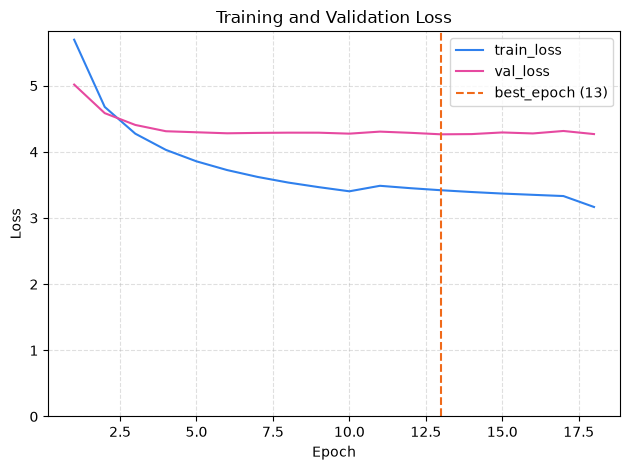

In [24]:
plot_training_history(**trainer.history, best_epoch=trainer.best_epoch)

In [25]:
def translate(
    model: nn.Module,
    sentence: str,
    sp_en: spm.SentencePieceProcessor,
    sp_ru: spm.SentencePieceProcessor,
) -> tuple[str, list[str], torch.Tensor]:
    """Translates an English sentence into Russian using a trained model.

    Args:
        model: A trained encoder-decoder seq2seq model.
        sentence: The English sentence to translate.
        sp_en: SentencePiece model used to encode ``sentence``.
        sp_ru: SentencePiece model used to decode the model's output.

    Returns:
        A tuple of the predicted translation, the decoded subword pieces,
        and the attention weights.
    """
    model.eval()
    device = next(model.parameters()).device

    ids = [sp_en.bos_id(), *sp_en.encode(sentence, out_type=int), sp_en.eos_id()]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        logits, attention = model.forward_with_attention(x)

    pred_ids = logits[0].argmax(dim=-1).tolist()

    eos_id = sp_ru.eos_id()
    if eos_id in pred_ids:
        pred_ids = pred_ids[: pred_ids.index(eos_id)]

    output_pieces = [sp_ru.id_to_piece(i) for i in pred_ids]
    attention = attention[0, : len(pred_ids)]

    return sp_ru.decode(pred_ids), output_pieces, attention

In [38]:
sentence = "she asked me to close the door"

output, output_tokens, attentions = translate(model, sentence, sp_en, sp_ru)

print(f"> {sentence}")
print(f"= {output_tokens}")
print(f"< {output}")

> she asked me to close the door
= ['▁Она', '▁попросил', 'а', '▁меня', '▁за', 'крыть', '▁дверь', '.']
< Она попросила меня закрыть дверь.


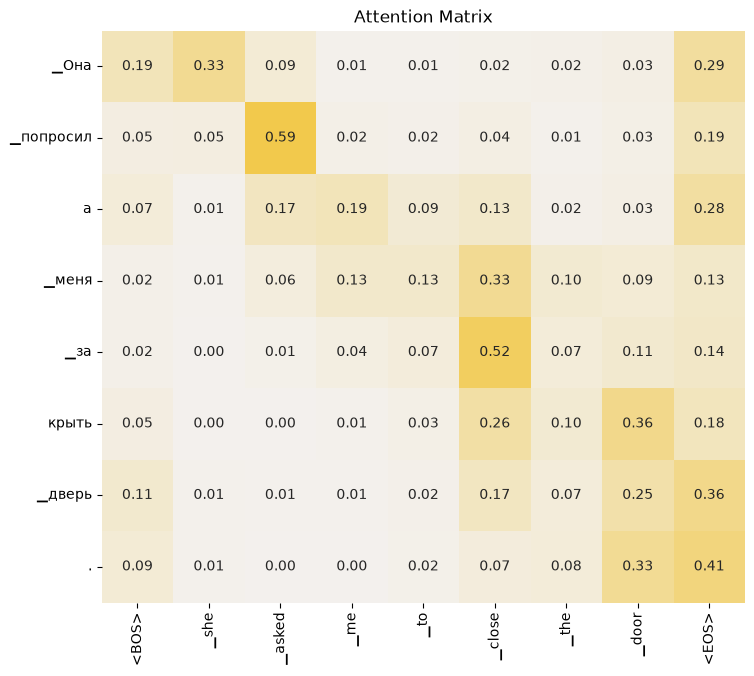

In [39]:
input_tokens = ["<BOS>", *sp_en.encode(sentence, out_type=str), "<EOS>"]

plot_attention_matrix(input_tokens, output_tokens, attentions)